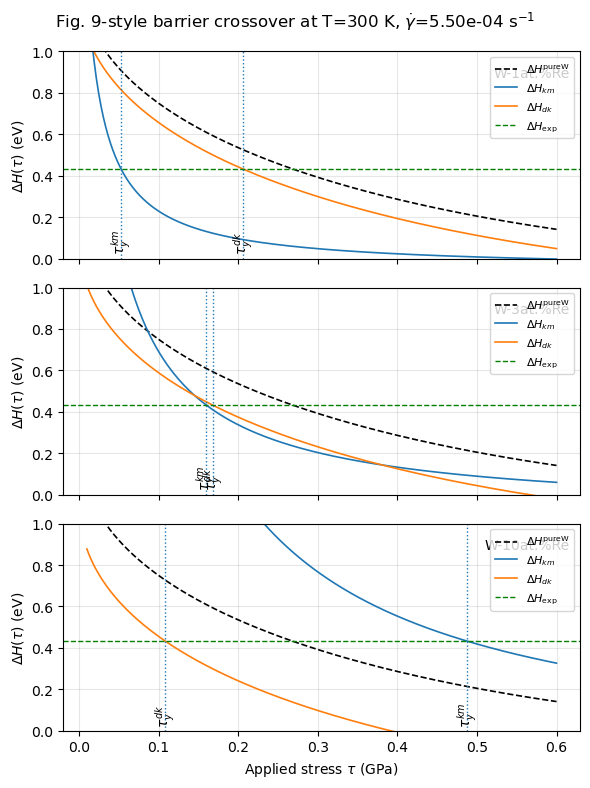

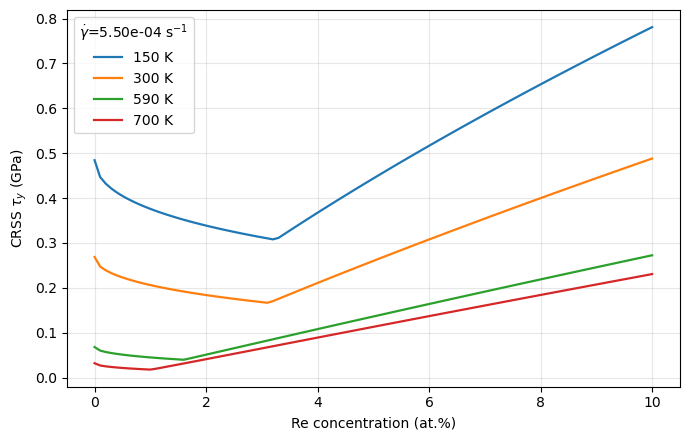

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Constants / units
# =========================
kB_eV = 8.617333262145e-5      # eV/K
eV_to_J = 1.602176634e-19      # J/eV

# =========================
# W / W-Re parameters used in Ghafarollahi & Curtin (illustrative)
# =========================
# From their W-Re application discussion:
H0_0_eV   = 1.4       # ΔH0(0) [eV]  (Kocks fit)  :contentReference[oaicite:7]{index=7}
tauP_Pa   = 1.1e9     # τP [Pa] (=1.1 GPa)         :contentReference[oaicite:8]{index=8}
p_kocks   = 0.49
q_kocks   = 1.69

# Geometry / line length and kink width used in their W-Re illustrations:
L = 1.0e-6             # m (L=1 μm from ρ=1e12 m^-2) :contentReference[oaicite:9]{index=9}
a0 = 3.1652e-10        # m (W lattice parameter; your value)
b  = (a0*np.sqrt(3)/2) # m
a  = 0.943*b           # m (distance between Peierls valleys used in their nucleation TS discussion) :contentReference[oaicite:10]{index=10}
w  = 12.0*b            # kink width (they use w=12b) :contentReference[oaicite:11]{index=11}

# Reference rate used to define ΔH_exp
dotgamma0 = 1.0e4      # s^-1 :contentReference[oaicite:12]{index=12}

# Strain rate for Stephens data (used in their W-Re example)
dotgamma_stephens = 5.5e-4  # s^-1 :contentReference[oaicite:13]{index=13}

# =========================
# Table 1: G(tau/tau_p) from Ghafarollahi & Curtin (2020)
# =========================
# τ/τp, G(τ/τp)  :contentReference[oaicite:14]{index=14}
G_x = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], dtype=float)
G_y = np.array([3.07, 3.07, 2.55, 2.20, 1.94, 1.77, 1.64, 1.52, 1.39, 1.06, 0.0], dtype=float)

def G_of_tau(tau_Pa):
    """Interpolate Table-1 G(τ/τp). Clamp to [0,1]."""
    x = np.clip(np.asarray(tau_Pa, dtype=float)/tauP_Pa, 0.0, 1.0)
    # return np.interp(x, G_x, G_y)
    return 1.0

# =========================
# Material-specific solute parameter for W-Re
# =========================
def Etilde_p_eV(c_atfrac):
    """
    \u0394E~p = 345 sqrt(c) meV = 0.345 sqrt(c) eV for W-Re.
    c is atomic fraction (e.g. 0.01 for 1 at.%).
    :contentReference[oaicite:15]{index=15}
    """
    c = max(float(c_atfrac), 0.0)
    return 0.345*np.sqrt(c)

def tau_c_Pa(c_atfrac):
    """Characteristic stress τc = \u0394E~p / (a b^2)  (their Eq. 8 definition used in migration model). :contentReference[oaicite:16]{index=16}"""
    Ep_J = Etilde_p_eV(c_atfrac)*eV_to_J
    if Ep_J <= 0:
        return np.nan
    return Ep_J/(a*b*b)

# =========================
# Barriers
# =========================
def Hexp_eV(T_K, dotgamma=dotgamma_stephens):
    """ΔH_exp = kT ln(dot0/dot)  (Eq. 13). :contentReference[oaicite:17]{index=17}"""
    return kB_eV*T_K*np.log(dotgamma0/dotgamma)

def H0_kocks_eV(tau_Pa):
    """Pure W nucleation barrier (Kocks form used in their W-Re fit). :contentReference[oaicite:18]{index=18}"""
    x = np.asarray(tau_Pa, dtype=float)/tauP_Pa
    out = np.zeros_like(x)
    mask = x < 1.0
    out[mask] = H0_0_eV*(1.0 - x[mask]**p_kocks)**q_kocks
    return out

def extreme_value_factor(N):
    """The bracketed extreme-value factor in Eq. (16) (same as your log_term). :contentReference[oaicite:19]{index=19}"""
    lnN = np.log(N)
    return (np.log(4*np.pi*lnN) - 4*lnN - 1.1544)/np.sqrt(8*lnN)

def Hsol_bar_eV(tau_Pa, c_atfrac):
    """
    \u0394Hbar_sol = \u0394E~p * G(τ) * extreme_value_factor, with N = L/(2w).
    Eq. (16). :contentReference[oaicite:20]{index=20}
    """
    Ep = Etilde_p_eV(c_atfrac)
    if Ep <= 0:
        return 0.0
    N = L/(2.0*w)
    return Ep*G_of_tau(tau_Pa)*extreme_value_factor(N)

def Hdk_eV(tau_Pa, c_atfrac):
    """Eq. (15): ΔH_dk = ΔH0 + ΔHbar_sol. :contentReference[oaicite:21]{index=21}"""
    return H0_kocks_eV(tau_Pa) + Hsol_bar_eV(tau_Pa, c_atfrac)

def Hkm_eV(tau_Pa, c_atfrac):
    """
    Eq. (10): ΔH_km = ΔE~p * [ 3.26/(τ/τc + 2.7/sqrt(L/b)) + 0.035*sqrt(L/b) - 1.07*sqrt(w/b) ].
    :contentReference[oaicite:22]{index=22}
    """
    Ep = Etilde_p_eV(c_atfrac)
    if Ep <= 0:
        return np.zeros_like(np.asarray(tau_Pa, dtype=float))

    tau = np.asarray(tau_Pa, dtype=float)
    tc  = tau_c_Pa(c_atfrac)

    X = np.sqrt(L/b)
    term = (tau/tc) + 2.7/(X)  # 2.7*(L/b)^(-1/2)
    # Protect division
    term = np.maximum(term, 1e-30)

    bracket = 3.26/term + 0.035*X - 1.07*np.sqrt(w/b)
    return Ep*bracket

# =========================
# Yield stresses (solve ΔH(τ)=ΔH_exp)
# =========================
def bisect_root(func, lo, hi, niter=200, tol=1e-8):
    flo = func(lo)
    fhi = func(hi)
    if np.isnan(flo) or np.isnan(fhi):
        return np.nan
    if flo == 0.0:
        return lo
    if fhi == 0.0:
        return hi
    if flo*fhi > 0:
        return np.nan
    for _ in range(niter):
        mid = 0.5*(lo+hi)
        fmid = func(mid)
        if np.isnan(fmid):
            return np.nan
        if abs(fmid) < tol:
            return mid
        if flo*fmid <= 0:
            hi = mid
            fhi = fmid
        else:
            lo = mid
            flo = fmid
    return 0.5*(lo+hi)

def tau_y_km(T_K, c_atfrac, dotgamma=dotgamma_stephens):
    """
    Eq. (14): analytic inversion of Eq. (10) for migration-controlled strength.
    :contentReference[oaicite:23]{index=23}
    """
    Ep = Etilde_p_eV(c_atfrac)
    if Ep <= 0:
        return np.nan
    Hexp = Hexp_eV(T_K, dotgamma=dotgamma)
    tc = tau_c_Pa(c_atfrac)

    X = np.sqrt(L/b)
    denom = (Hexp/Ep) - 0.035*X + 1.07*np.sqrt(w/b)
    if denom <= 0:
        return np.nan

    return tc*(3.26/denom - 2.7*np.sqrt(b/L))

def tau_y_dk(T_K, c_atfrac, dotgamma=dotgamma_stephens):
    """Solve ΔH_dk(τ,c)=ΔH_exp(T)."""
    Htarget = Hexp_eV(T_K, dotgamma=dotgamma)
    f = lambda tau: Hdk_eV(tau, c_atfrac) - Htarget
    # bracket in Pa
    lo = 1e6
    hi = tauP_Pa*0.999999
    return bisect_root(f, lo, hi)

def tau_y_total(T_K, c_atfrac, dotgamma=dotgamma_stephens):
    """
    Controlling CRSS = max(τ_y^dk, τ_y^km).
    This is the same controlling-mechanism logic used to build the CRSS-vs-c plots. :contentReference[oaicite:24]{index=24}
    """
    if c_atfrac <= 0:
        # pure W: no solute barriers; solve pure nucleation barrier = Hexp
        return tau_y_dk(T_K, 0.0, dotgamma=dotgamma)

    tdk = tau_y_dk(T_K, c_atfrac, dotgamma=dotgamma)
    tkm = tau_y_km(T_K, c_atfrac, dotgamma=dotgamma)
    # If either is nan, fall back to the other
    vals = [v for v in [tdk, tkm] if np.isfinite(v)]
    return np.max(vals) if vals else np.nan

# =========================
# FIGURE 9: barrier curves (3 panels: 1, 3, 10 at.% Re)
# =========================
def plot_fig9_like(T_K=300.0, c_list=(0.01, 0.03, 0.10), dotgamma=dotgamma_stephens):
    tau_GPa = np.linspace(0.01, 0.60, 400)  # 0.01..0.6 GPa
    tau_Pa  = tau_GPa*1e9
    Hline   = Hexp_eV(T_K, dotgamma=dotgamma)

    fig, axes = plt.subplots(len(c_list), 1, figsize=(6.0, 8.0), sharex=True)
    if len(c_list) == 1:
        axes = [axes]

    for ax, c in zip(axes, c_list):
        H_pure = H0_kocks_eV(tau_Pa)
        H_km   = Hkm_eV(tau_Pa, c)
        H_dk   = Hdk_eV(tau_Pa, c)

        ax.plot(tau_GPa, H_pure, 'k--', lw=1.2, label=r'$\Delta H^{\rm pureW}$')
        ax.plot(tau_GPa, H_km,   lw=1.2, label=r'$\Delta H_{km}$')
        ax.plot(tau_GPa, H_dk,   lw=1.2, label=r'$\Delta H_{dk}$')

        ax.axhline(Hline, ls='--', lw=1.0, color='green', label=r'$\Delta H_{\rm exp}$')

        # mark τy^km and τy^dk
        tkm = tau_y_km(T_K, c, dotgamma=dotgamma)
        tdk = tau_y_dk(T_K, c, dotgamma=dotgamma)
        if np.isfinite(tkm):
            ax.axvline(tkm/1e9, ls=':', lw=1.0)
            ax.text(tkm/1e9, 0.02, r'$\tau_y^{km}$', rotation=90, va='bottom', ha='center')
        if np.isfinite(tdk):
            ax.axvline(tdk/1e9, ls=':', lw=1.0)
            ax.text(tdk/1e9, 0.02, r'$\tau_y^{dk}$', rotation=90, va='bottom', ha='center')

        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel(r'$\Delta H(\tau)$ (eV)')
        ax.text(0.98, 0.93, f"W-{c*100:.0f}at.%Re", transform=ax.transAxes,
                ha='right', va='top')

        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel(r'Applied stress $\tau$ (GPa)')
    fig.suptitle(f"Fig. 9-style barrier crossover at T={T_K:.0f} K, $\dot\\gamma$={dotgamma:.2e} s$^{{-1}}$")
    fig.tight_layout()
    plt.show()

# =========================
# FIGURE 11: CRSS vs Re concentration at multiple temperatures
# =========================
def plot_fig11_like(T_list=(150, 300, 590, 700), cmax_atpct=10.0, npts=101, dotgamma=dotgamma_stephens):
    c_atfrac = np.linspace(0.0, cmax_atpct/100.0, npts)
    plt.figure(figsize=(7.0, 4.5))

    for T in T_list:
        tau_vals = np.array([tau_y_total(T, c, dotgamma=dotgamma) for c in c_atfrac])
        plt.plot(c_atfrac*100.0, tau_vals/1e9, lw=1.6, label=f"{T} K")

    plt.xlabel("Re concentration (at.%)")
    plt.ylabel(r"CRSS $\tau_y$ (GPa)")
    plt.grid(True, alpha=0.3)
    plt.legend(title=f"$\\dot\\gamma$={dotgamma:.2e} s$^{{-1}}$")
    plt.tight_layout()
    plt.show()

# =========================
# Run both reproductions
# =========================
if __name__ == "__main__":
    # Fig 9-style barriers (choose T to match your target figure)
    plot_fig9_like(T_K=300.0, c_list=(0.01, 0.03, 0.10), dotgamma=dotgamma_stephens)

    # Fig 11-style CRSS vs concentration
    plot_fig11_like(T_list=(150, 300, 590, 700), cmax_atpct=10.0, npts=101, dotgamma=dotgamma_stephens)
